In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, r2_score, roc_auc_score
from imblearn.over_sampling import SMOTE

df = pd.read_csv('Blockchain_Cryptocurrency_Transaction_Risk_Dataset.csv')

X = df.drop(['transaction_id', 'wallet_id', 'risk_label'], axis=1)
y = df['risk_label']

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
def evaluate_model(model, name, X_tst, y_tst):
    predictions = model.predict(X_tst)
    probs = model.predict_proba(X_tst)[:, 1] if hasattr(model, "predict_proba") else predictions

    print(f"--- {name} Performance ---")
    print(f"Accuracy: {accuracy_score(y_tst, predictions):.4f}")
    print(f"R-Squared (Pseudo): {r2_score(y_tst, predictions):.4f}")
    print(f"ROC-AUC Score: {roc_auc_score(y_tst, probs):.4f}")

    cm = confusion_matrix(y_tst, predictions)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

    print(classification_report(y_tst, predictions))
    print("-" * 30)

print("Preprocessing Complete. Dataset is scaled and balanced.")

Preprocessing Complete. Dataset is scaled and balanced.


--- Logistic Regression Performance ---
Accuracy: 0.6086
R-Squared (Pseudo): -0.5656
ROC-AUC Score: 0.6101


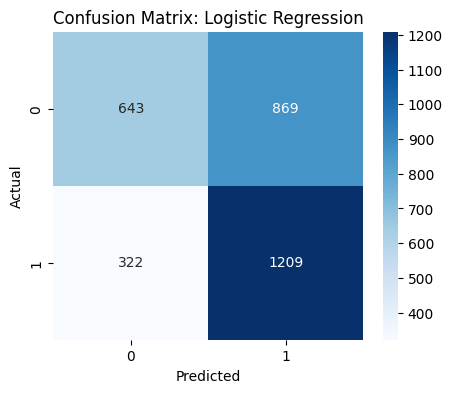

              precision    recall  f1-score   support

           0       0.67      0.43      0.52      1512
           1       0.58      0.79      0.67      1531

    accuracy                           0.61      3043
   macro avg       0.62      0.61      0.59      3043
weighted avg       0.62      0.61      0.60      3043

------------------------------


In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

evaluate_model(lr_model, "Logistic Regression", X_test_scaled, y_test)

--- Random Forest Performance ---
Accuracy: 0.8193
R-Squared (Pseudo): 0.2770
ROC-AUC Score: 0.8831


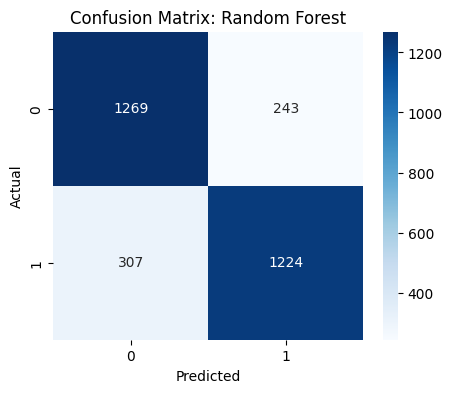

              precision    recall  f1-score   support

           0       0.81      0.84      0.82      1512
           1       0.83      0.80      0.82      1531

    accuracy                           0.82      3043
   macro avg       0.82      0.82      0.82      3043
weighted avg       0.82      0.82      0.82      3043

------------------------------


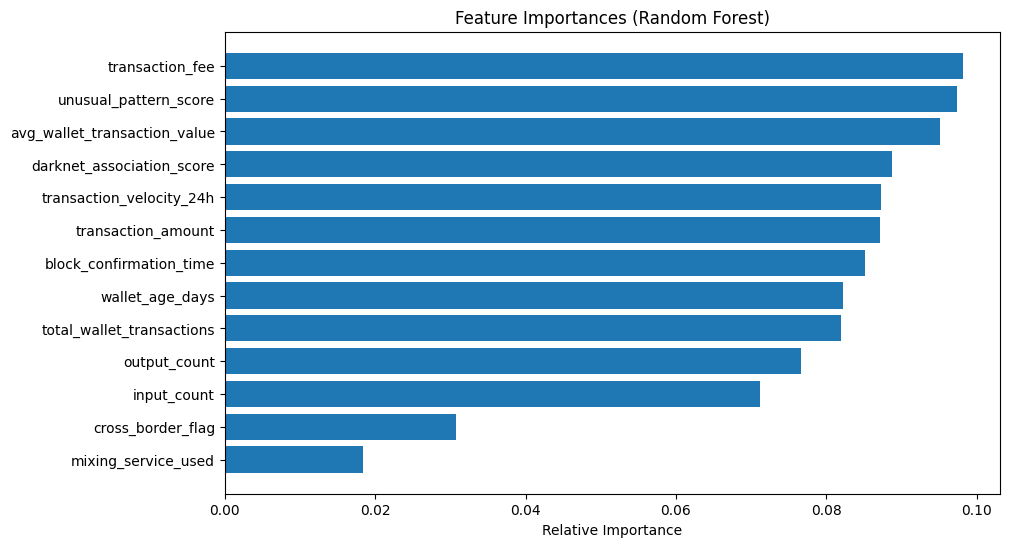

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

evaluate_model(rf_model, "Random Forest", X_test_scaled, y_test)

importances = rf_model.feature_importances_
feat_names = X.columns
indices = np.argsort(importances)

plt.figure(figsize=(10,6))
plt.title('Feature Importances (Random Forest)')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feat_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:58:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- XGBoost Performance ---
Accuracy: 0.8061
R-Squared (Pseudo): 0.2244
ROC-AUC Score: 0.8794


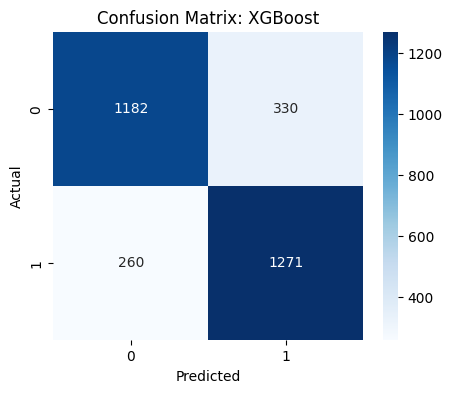

              precision    recall  f1-score   support

           0       0.82      0.78      0.80      1512
           1       0.79      0.83      0.81      1531

    accuracy                           0.81      3043
   macro avg       0.81      0.81      0.81      3043
weighted avg       0.81      0.81      0.81      3043

------------------------------


In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_scaled, y_train)

evaluate_model(xgb_model, "XGBoost", X_test_scaled, y_test)

--- SVM Performance ---
Accuracy: 0.7394
R-Squared (Pseudo): -0.0424
ROC-AUC Score: 0.8078


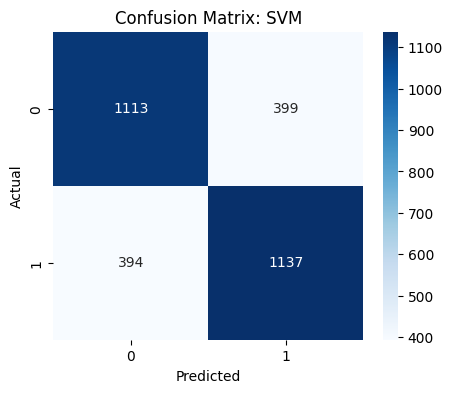

              precision    recall  f1-score   support

           0       0.74      0.74      0.74      1512
           1       0.74      0.74      0.74      1531

    accuracy                           0.74      3043
   macro avg       0.74      0.74      0.74      3043
weighted avg       0.74      0.74      0.74      3043

------------------------------


In [ ]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)

evaluate_model(svm_model, "SVM", X_test_scaled, y_test)

Summary Table:


,Model,Accuracy,R2 Score,ROC-AUC
0,Logistic Regression,0.608610,-0.565621,0.610099
1,Random Forest,0.819257,0.277001,0.883130
2,XGBoost,0.806112,0.224419,0.879444
3,SVM,0.739402,-0.042433,0.807773


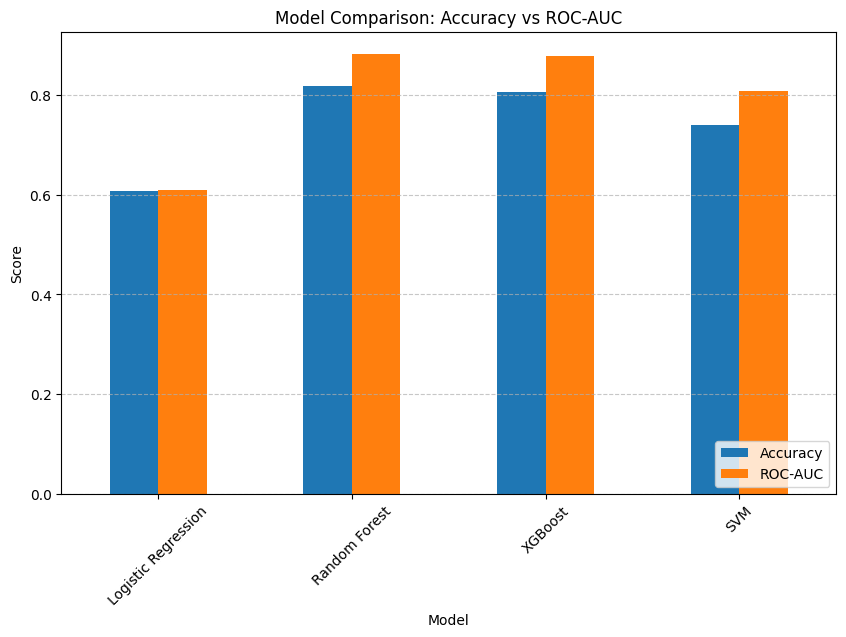

In [ ]:
# --- FINAL COMPARISON CELL ---
import pandas as pd

results = []

models = [
    (lr_model, "Logistic Regression"),
    (rf_model, "Random Forest"),
    (xgb_model, "XGBoost"),
    (svm_model, "SVM")
]

for model, name in models:
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    r2 = r2_score(y_test, preds)
    probs = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else preds
    auc = roc_auc_score(y_test, probs)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "R2 Score": r2,
        "ROC-AUC": auc
    })

comparison_df = pd.DataFrame(results)
print("Summary Table:")
display(comparison_df)

comparison_df.to_csv('model_comparison_results.csv', index=False)

comparison_df.set_index('Model')[['Accuracy', 'ROC-AUC']].plot(kind='bar', figsize=(10, 6))
plt.title('Model Comparison: Accuracy vs ROC-AUC')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='lower right')
plt.show()